# **SuperKart Sales Forecasting - Model Deployment Project**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use sales forecasts to estimate weekly, monthly, quarterly, and annual sales totals. An accurate sales forecast adds value across the organization - it helps supply chain teams plan procurement, enables region-wise sales planning, improves decision-making about the future, and establishes benchmarks for assessing future trends.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities. To optimize inventory management and support regional sales strategy, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter. As the partnering data science team, our goal is twofold:

1. Build a predictive model that forecasts `Product_Store_Sales_Total` from product and store attributes.
2. Deploy the model as a production-ready service - a Flask REST API (backend) and a Streamlit web application (frontend), each containerized with Docker and served from a **GitHub Codespace** through public forwarded URLs.

## Data Dictionary

- `Product_Id`: Unique identifier of each product; two letters at the beginning followed by a number
- `Product_Weight`: Weight of each product
- `Product_Sugar_Content`: Sugar content of each product (Low Sugar, Regular, No Sugar)
- `Product_Allocated_Area`: Ratio of the product's allocated display area to the total display area in the store
- `Product_Type`: Broad category of the product (meat, snack foods, dairy, etc.)
- `Product_MRP`: Maximum retail price of the product
- `Store_Id`: Unique identifier of each store
- `Store_Establishment_Year`: Year in which the store was established
- `Store_Size`: Size of the store (High, Medium, Small)
- `Store_Location_City_Type`: Tier of the city the store is located in (Tier 1, Tier 2, Tier 3)
- `Store_Type`: Type of store (Departmental Store, Supermarket Type 1, Supermarket Type 2, Food Mart)
- `Product_Store_Sales_Total`: Total revenue generated by the sale of that product in that store **(target variable)**

# **Installing and Importing the Necessary Libraries**

In [1]:
# Uncomment the line below to install the required libraries (with the versions used to build this project)
# !pip install numpy==2.2.6 pandas==2.3.3 scikit-learn==1.7.2 matplotlib==3.10.9 seaborn==0.13.2 xgboost==3.2.0 joblib==1.5.3

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Pipeline and preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Serialization
import joblib

import os

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


# **Loading the Dataset**

In [3]:
# Load the SuperKart dataset
data = pd.read_csv("SuperKart.csv")

# Keep an untouched copy so the original data is always available for reference
df = data.copy()

df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [4]:
# Shape of the data
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 8763 rows and 12 columns.


In [5]:
# Data types of the various attributes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [6]:
# Checking for missing values
df.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

In [7]:
# Checking for duplicate rows and duplicate product-store records
print("Number of fully duplicated rows:", df.duplicated().sum())
print("Number of duplicated Product Ids:", df["Product_Id"].duplicated().sum())

Number of fully duplicated rows: 0
Number of duplicated Product Ids: 0


In [8]:
# Statistical summary of the numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [9]:
# Statistical summary of the categorical columns
df.describe(include="object").T

,count,unique,top,freq
Product_Id,8763,8763,FD306,1
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


**Observations - Data Overview**

- The dataset contains **8,763 rows and 12 columns** - each row is a unique product-store combination (no duplicate rows and no duplicate `Product_Id` values).
- There are **no missing values** in any column - imputation is not required.
- 4 numerical predictors (`Product_Weight`, `Product_Allocated_Area`, `Product_MRP`, `Store_Establishment_Year`), 7 categorical/identifier columns, and the numerical target `Product_Store_Sales_Total`.
- `Product_Weight` ranges from ~4 to 22 with a mean around 12.65. `Product_MRP` averages ~147 with a max of 266.
- The target `Product_Store_Sales_Total` has mean ~3,464 and ranges up to 8,000 - a fairly wide revenue spread across product-store combinations.
- `Product_Sugar_Content` shows **4 unique values** although the data dictionary defines only 3 - there is a stray `'reg'` label that needs to be standardized to `'Regular'` during preprocessing.
- There are only **4 stores** (`OUT001`-`OUT004`) and 16 product types.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [10]:
# Utility function: histogram + boxplot for a numerical column
def histogram_boxplot(frame, feature, bins=30):
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize=(10, 5)
    )
    sns.boxplot(data=frame, x=feature, ax=ax_box, color="violet", showmeans=True)
    sns.histplot(data=frame, x=feature, bins=bins, ax=ax_hist, kde=True)
    ax_hist.axvline(frame[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist.axvline(frame[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist.legend()
    ax_box.set_title(f"Distribution of {feature}")
    plt.show()

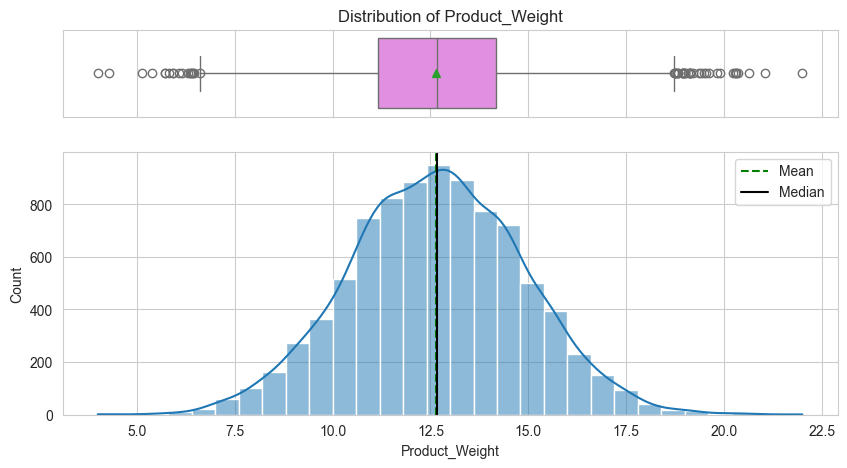

In [11]:
histogram_boxplot(df, "Product_Weight")

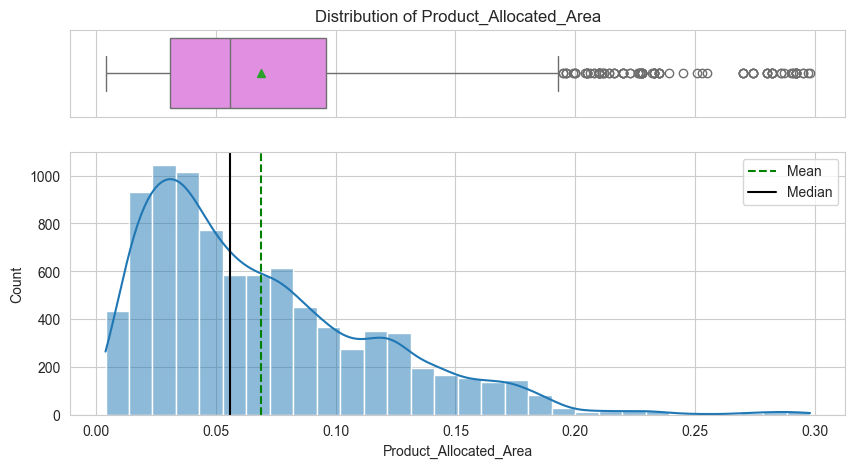

In [12]:
histogram_boxplot(df, "Product_Allocated_Area")

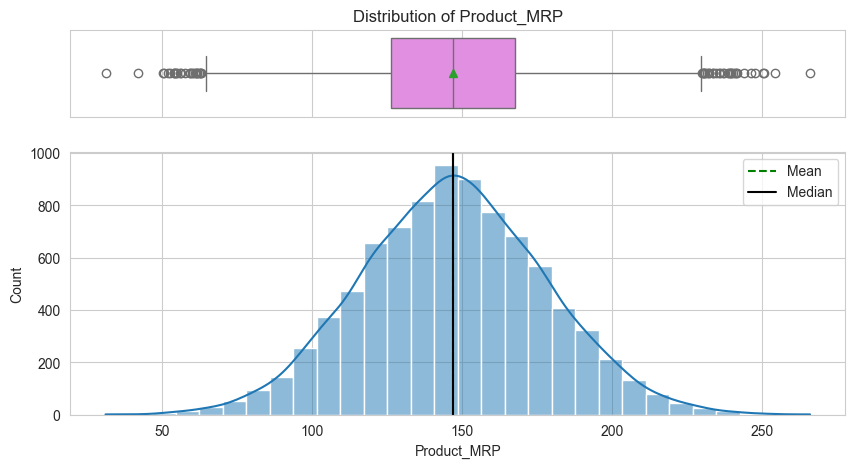

In [13]:
histogram_boxplot(df, "Product_MRP")

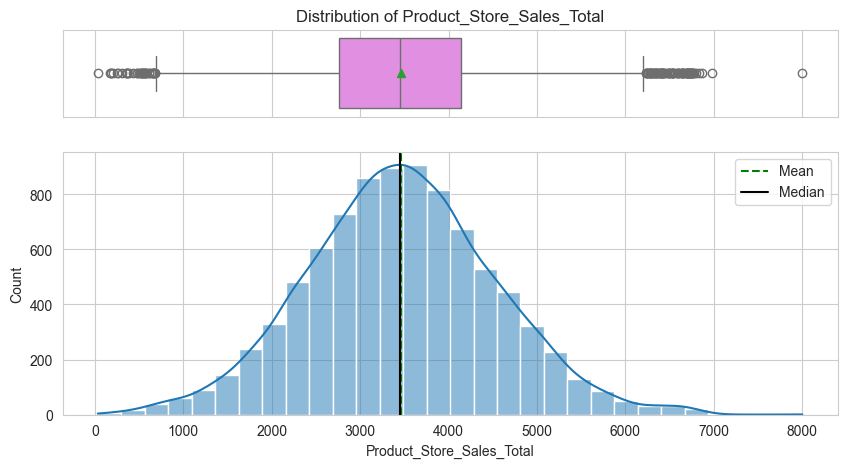

In [14]:
histogram_boxplot(df, "Product_Store_Sales_Total")

In [15]:
# Utility function: labeled barplot for a categorical column
def labeled_barplot(frame, feature, rotation=0):
    plt.figure(figsize=(10, 4))
    ax = sns.countplot(data=frame, x=feature, order=frame[feature].value_counts().index, palette="Paired")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom")
    plt.xticks(rotation=rotation)
    plt.title(f"Count of observations by {feature}")
    plt.show()

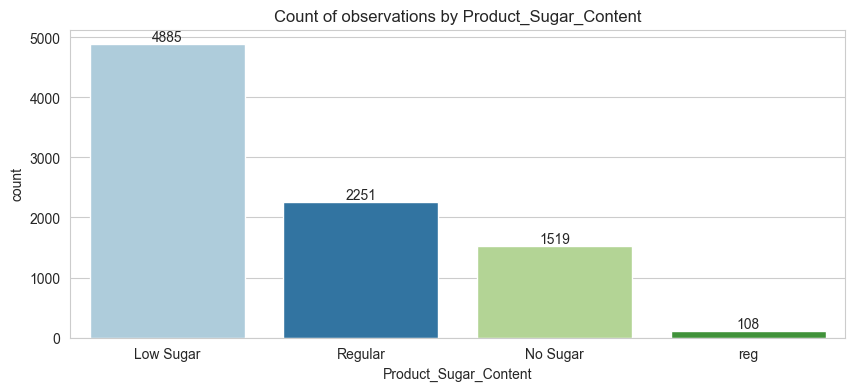

In [16]:
labeled_barplot(df, "Product_Sugar_Content")

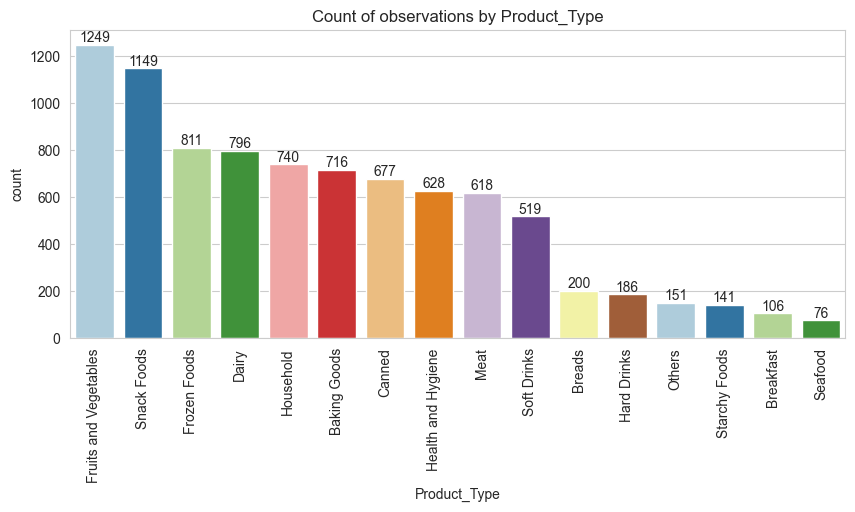

In [17]:
labeled_barplot(df, "Product_Type", rotation=90)

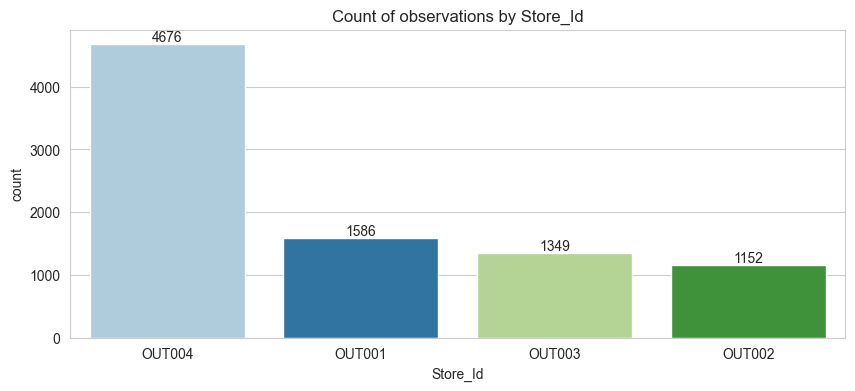

In [18]:
labeled_barplot(df, "Store_Id")

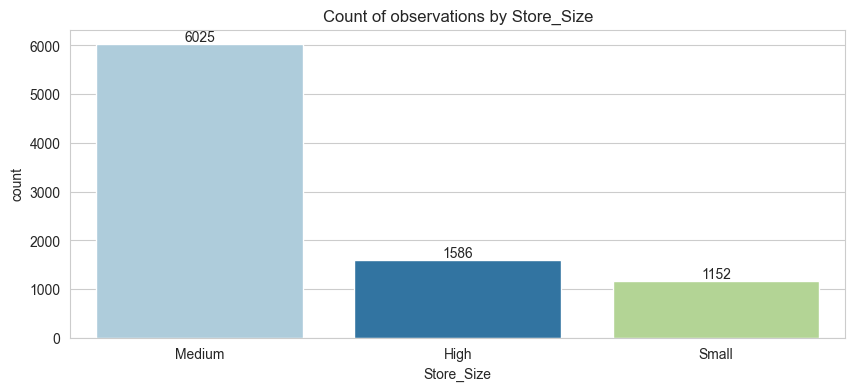

In [19]:
labeled_barplot(df, "Store_Size")

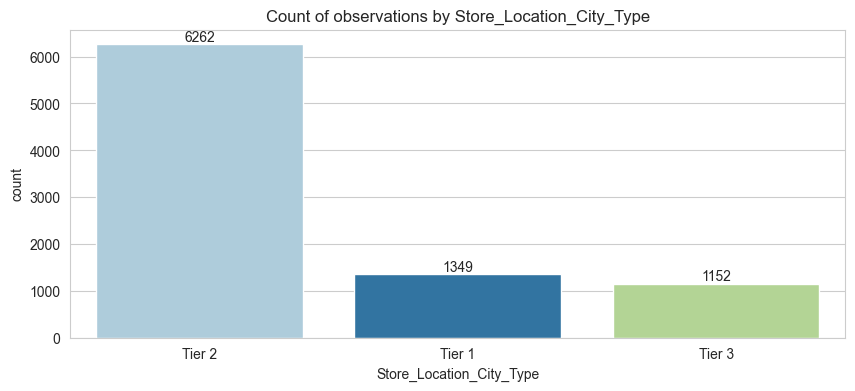

In [20]:
labeled_barplot(df, "Store_Location_City_Type")

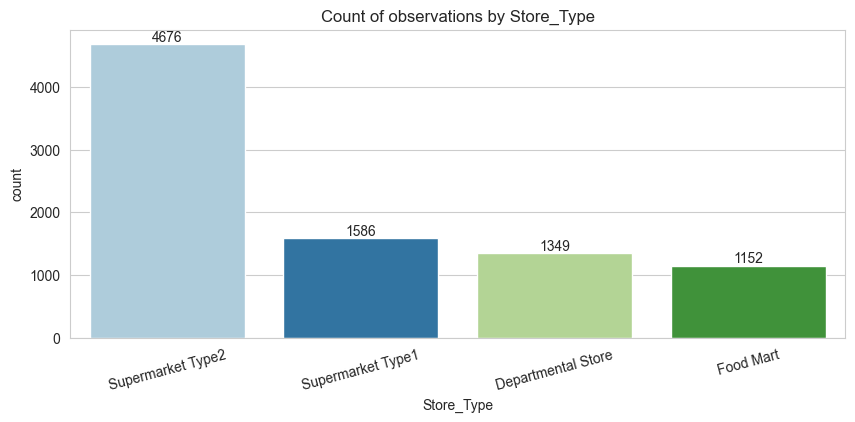

In [21]:
labeled_barplot(df, "Store_Type", rotation=15)

**Observations - Univariate Analysis**

- `Product_Weight` and `Product_MRP` are approximately **normally distributed** with only a few mild outliers on either side of the whiskers.
- `Product_Allocated_Area` is **right-skewed** - most products get a small share (<10%) of display area, with some outliers up to 30%.
- The target `Product_Store_Sales_Total` is roughly bell-shaped with a slight right tail and outliers on both ends - most product-store combinations generate between ~2,700 and ~4,100 in revenue.
- `Product_Sugar_Content` confirms the stray `'reg'` category, which is clearly a shorthand for `'Regular'` and will be merged during feature engineering. Low Sugar products dominate the catalogue.
- **Fruits and Vegetables** and **Snack Foods** are the most common product types.
- Store **OUT004 contributes the most records** (a Supermarket Type 2 in a Tier 2 city), followed by OUT001; Medium-size stores account for the largest share of rows.
- Supermarket Type 2 is the most frequent store type, and Tier 2 cities contribute the most observations.

## Bivariate Analysis

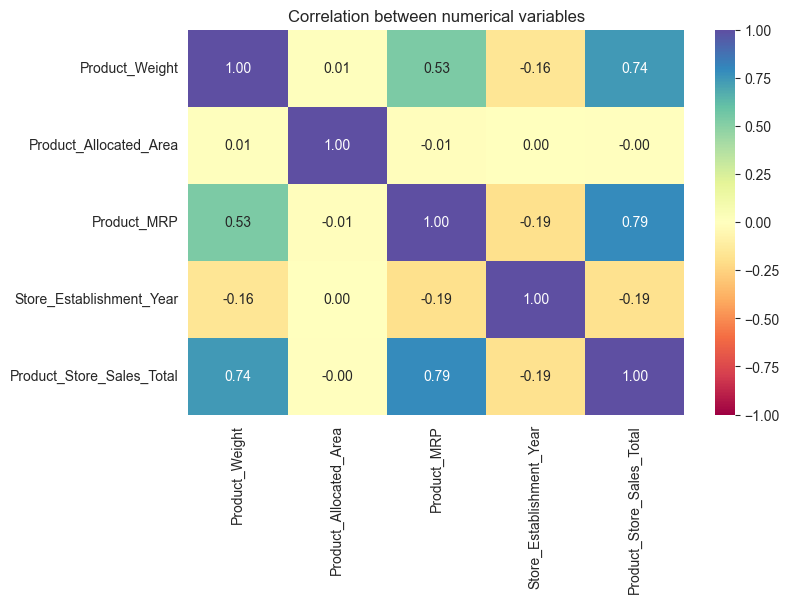

In [22]:
# Correlation heatmap between the numerical variables
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Establishment_Year", "Product_Store_Sales_Total"]
plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="Spectral", vmin=-1, vmax=1)
plt.title("Correlation between numerical variables")
plt.show()

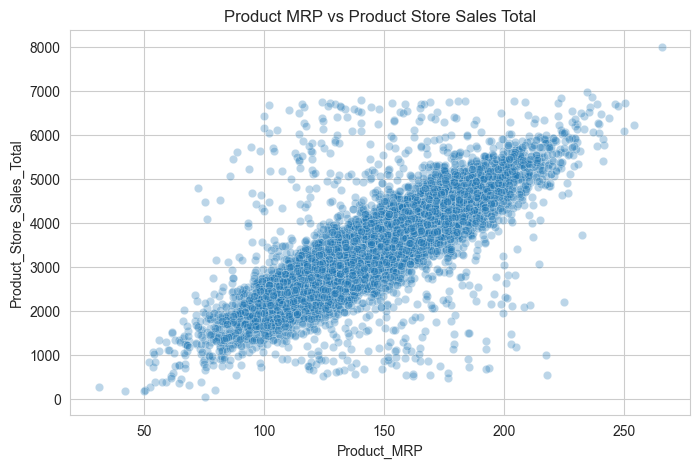

In [23]:
# Product MRP vs Sales
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Product_MRP", y="Product_Store_Sales_Total", alpha=0.3)
plt.title("Product MRP vs Product Store Sales Total")
plt.show()

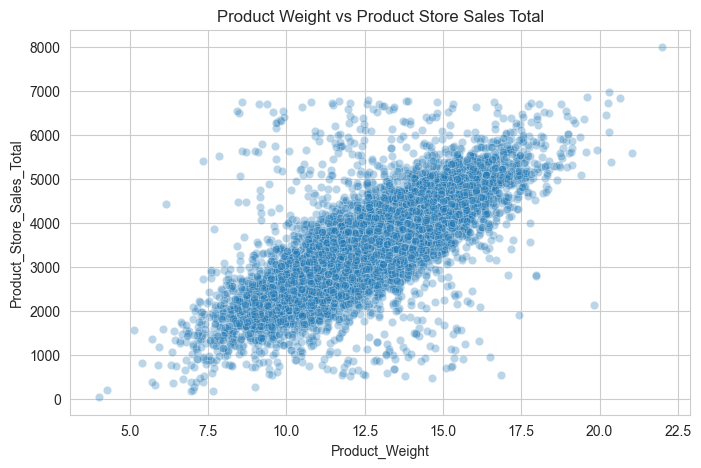

In [24]:
# Product Weight vs Sales
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Product_Weight", y="Product_Store_Sales_Total", alpha=0.3)
plt.title("Product Weight vs Product Store Sales Total")
plt.show()

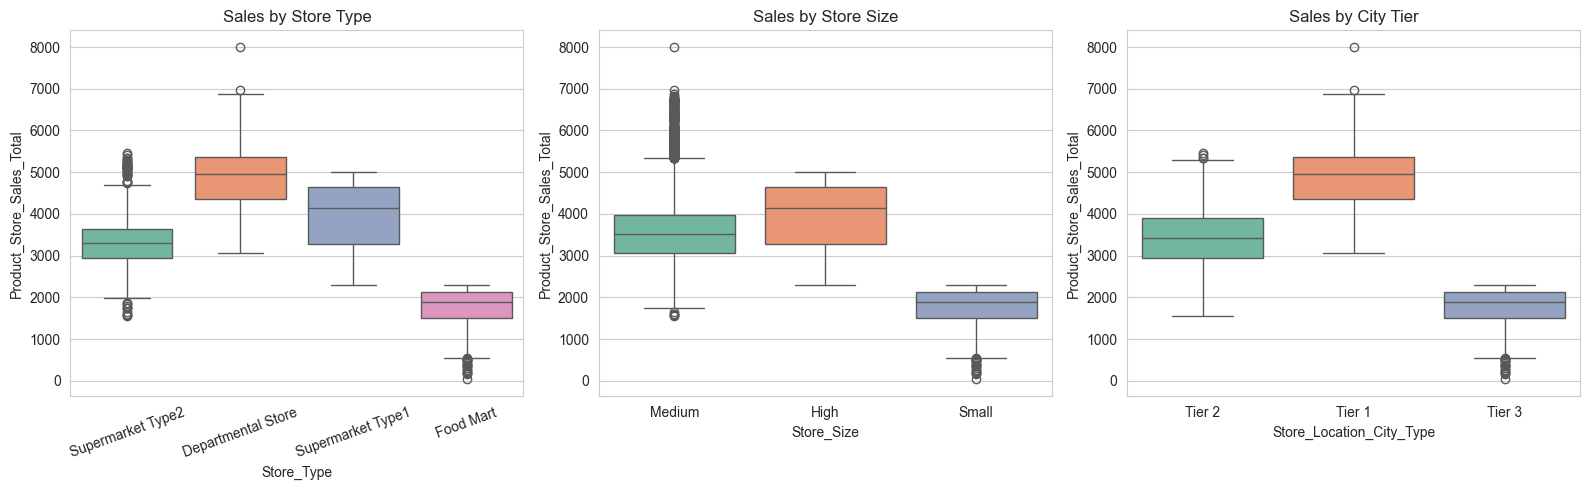

In [25]:
# Sales distribution across store-related attributes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x="Store_Type", y="Product_Store_Sales_Total", ax=axes[0], palette="Set2")
axes[0].set_title("Sales by Store Type"); axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=df, x="Store_Size", y="Product_Store_Sales_Total", ax=axes[1], palette="Set2")
axes[1].set_title("Sales by Store Size")
sns.boxplot(data=df, x="Store_Location_City_Type", y="Product_Store_Sales_Total", ax=axes[2], palette="Set2")
axes[2].set_title("Sales by City Tier")
plt.tight_layout(); plt.show()

In [26]:
# Average sales per store
df.groupby(["Store_Id", "Store_Type", "Store_Size", "Store_Location_City_Type"])["Product_Store_Sales_Total"].agg(["count", "mean", "sum"]).sort_values("mean", ascending=False)

,,,,count,mean,sum
Store_Id,Store_Type,Store_Size,Store_Location_City_Type,,,
OUT003,Departmental Store,Medium,Tier 1,1349,4946.966323,6673457.57
OUT001,Supermarket Type1,High,Tier 2,1586,3923.778802,6223113.18
OUT004,Supermarket Type2,Medium,Tier 2,4676,3299.312111,15427583.43
OUT002,Food Mart,Small,Tier 3,1152,1762.942465,2030909.72


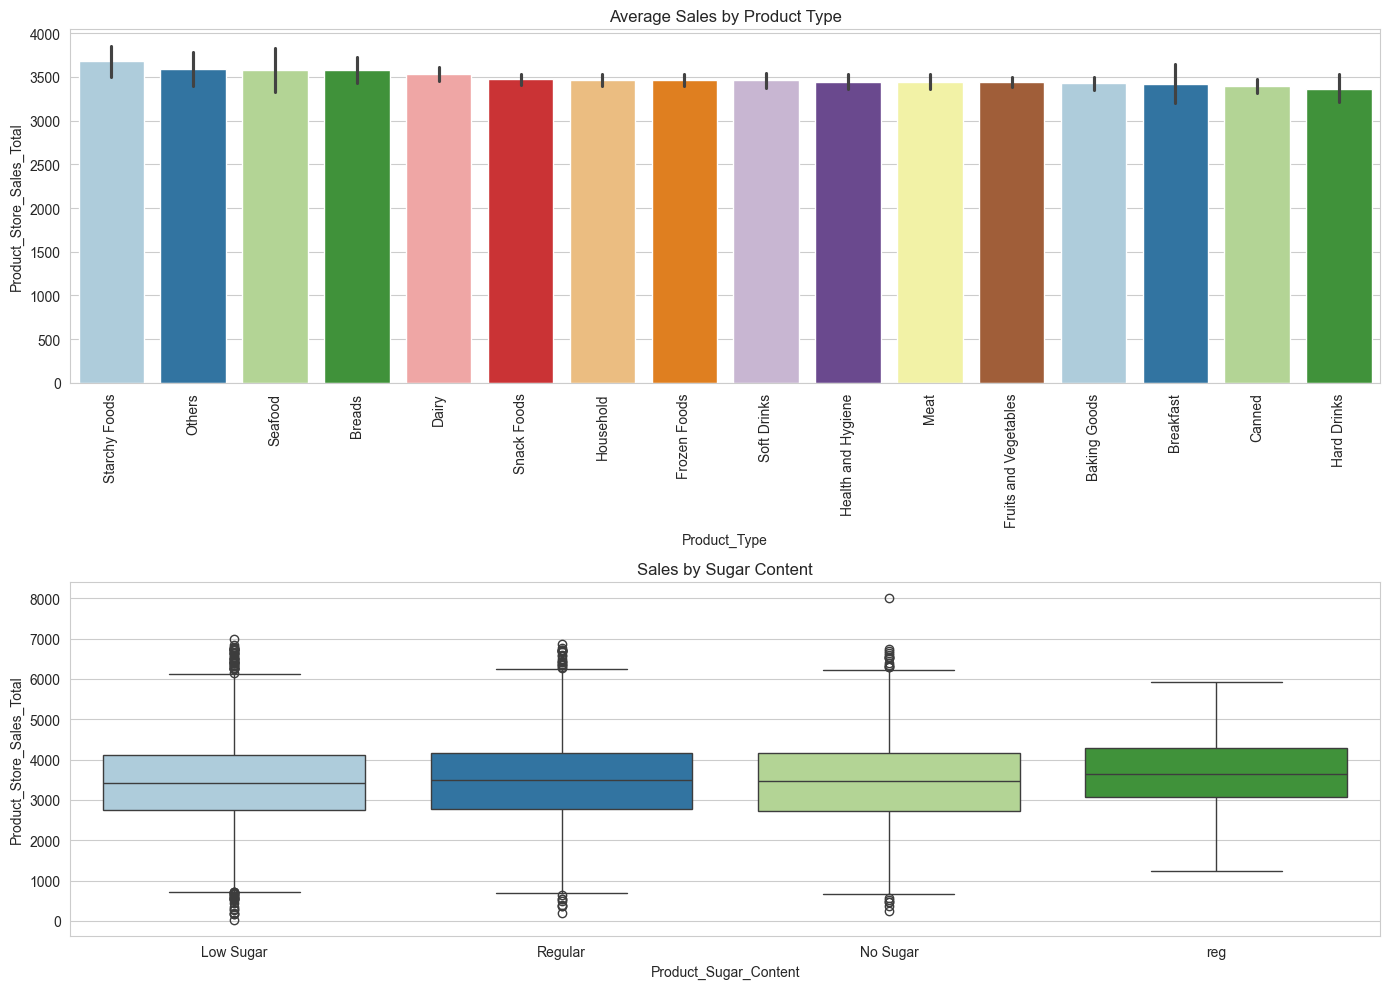

In [27]:
# Sales across product types and sugar content
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
order = df.groupby("Product_Type")["Product_Store_Sales_Total"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Product_Type", y="Product_Store_Sales_Total", order=order, ax=axes[0], palette="Paired")
axes[0].tick_params(axis="x", rotation=90); axes[0].set_title("Average Sales by Product Type")
sns.boxplot(data=df, x="Product_Sugar_Content", y="Product_Store_Sales_Total", ax=axes[1], palette="Paired")
axes[1].set_title("Sales by Sugar Content")
plt.tight_layout(); plt.show()

**Observations - Bivariate Analysis**

- **`Product_MRP` has a strong positive correlation with the target** - the scatter plot shows a clear upward trend, so price is expected to be the most important predictor.
- `Product_Weight` also shows a **moderate positive relationship** with sales; `Product_Allocated_Area` and `Store_Establishment_Year` show little linear relationship with the target.
- Per-product revenue differs markedly by store: the **Departmental Store (OUT003, Tier 1, Medium) leads with a mean of ~4,947 per product**, followed by Supermarket Type 1 (OUT001, ~3,924) and Supermarket Type 2 (OUT004, ~3,299), while the Food Mart (OUT002, Tier 3) trails far behind (~1,763).
- However, **OUT004 (Supermarket Type 2) generates the highest total revenue (~15.4M)** - more than OUT001 and OUT003 combined - purely on product volume (4,676 listings). Per-product strength and total-revenue strength sit in different stores.
- By city tier, **Tier 1 leads per product (~4,947) over Tier 2 (~3,457) and Tier 3 (~1,763)**, though Tier 2 dominates total revenue thanks to hosting two stores including OUT004.
- Average sales are quite uniform across product types and sugar content levels - product category matters far less than price and store characteristics.

**Insights based on EDA**

1. Price (`Product_MRP`) is the dominant driver of product-store revenue; product weight adds a secondary positive effect.
2. Store characteristics (type/size/city tier) create clear level shifts in revenue, so they must be part of the model. Notably, the per-product leader (OUT003, Departmental Store) is not the total-revenue leader (OUT004, Supermarket Type 2).
3. The `'reg'` label in `Product_Sugar_Content` must be merged into `'Regular'`.
4. The two-letter prefix of `Product_Id` (FD/DR/NC - Food/Drinks/Non-Consumable) is a compact product-category signal worth extracting as a feature.
5. Outliers in the numeric columns are mild and appear to be genuine market variation rather than data errors.


# **Data Preprocessing**

## Feature Engineering

- **Fix the label noise**: merge `'reg'` into `'Regular'` in `Product_Sugar_Content`.
- **`Product_Id_Prefix`**: the first two characters of `Product_Id` encode a high-level category - `FD` (Food), `DR` (Drinks), `NC` (Non-Consumable). We extract this as a new categorical feature and then drop the raw identifier (a unique ID carries no generalizable signal).
- **`Store_Age`**: convert `Store_Establishment_Year` into the age of the store (in years, relative to 2026, the year of this analysis). Age is more directly interpretable for the model and for business users than a raw year.

In [28]:
# Merge the stray 'reg' label into 'Regular'
df["Product_Sugar_Content"] = df["Product_Sugar_Content"].replace({"reg": "Regular"})
print(df["Product_Sugar_Content"].value_counts())

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


In [29]:
# Extract the two-letter product category prefix from the Product Id
df["Product_Id_Prefix"] = df["Product_Id"].str[:2]
print(df["Product_Id_Prefix"].value_counts())

Product_Id_Prefix
FD    6539
NC    1519
DR     705
Name: count, dtype: int64


In [30]:
# Convert establishment year into store age (reference year = 2026)
df["Store_Age"] = 2026 - df["Store_Establishment_Year"]

# Drop the columns that are no longer needed:
# - Product_Id: unique identifier, replaced by Product_Id_Prefix
# - Store_Establishment_Year: replaced by Store_Age
df = df.drop(columns=["Product_Id", "Store_Establishment_Year"])
df.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_Prefix,Store_Age
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,Medium,Tier 2,Supermarket Type2,2842.40,FD,17
1,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,Medium,Tier 1,Departmental Store,4830.02,FD,27
2,14.28,Regular,0.031,Canned,162.08,OUT001,High,Tier 2,Supermarket Type1,4130.16,FD,39
3,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,High,Tier 2,Supermarket Type1,4132.18,FD,39
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,Small,Tier 3,Food Mart,2279.36,NC,28


## Outlier Detection and Treatment

In [31]:
# Count outliers per numerical column using the IQR rule
for col in ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {n_out} outliers ({n_out / len(df) * 100:.2f}%)")

Product_Weight: 54 outliers (0.62%)
Product_Allocated_Area: 104 outliers (1.19%)
Product_MRP: 57 outliers (0.65%)
Product_Store_Sales_Total: 119 outliers (1.36%)


**Rationale - no outlier treatment applied**

- The share of IQR-flagged outliers is small (roughly 1-2% per column) and the values are plausible business quantities (premium-priced products, high-selling items), not data-entry errors.
- Both models we build (**Random Forest and XGBoost**) are tree-based and split on thresholds, which makes them **robust to outliers** - extreme values do not distort splits the way they distort linear coefficients.
- Capping or removing genuine high-revenue records would bias the model against exactly the products/stores the business most wants to understand. Hence, we retain all observations.

## Train-Test Split

In [32]:
# Separate the predictors and the target
X = df.drop(columns=["Product_Store_Sales_Total"])
y = df["Product_Store_Sales_Total"]

# 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (7010, 11)  Test: (1753, 11)


## Preprocessing Pipeline for Encoding Categorical Features

We define a `ColumnTransformer` that one-hot encodes every categorical column and passes the numerical columns through unchanged (tree-based models do not require feature scaling). `handle_unknown="ignore"` protects the deployed API from crashing if an unseen category value arrives at inference time - the unknown level is simply encoded as all zeros.

In [33]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print("Categorical:", cat_cols)
print("Numerical:  ", num_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="passthrough",  # numerical columns pass through unchanged
)
preprocessor

Categorical: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Id_Prefix']
Numerical:   ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']


,transformers,"[('onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


# **Model Building**

## Metric of Choice

The target is a continuous revenue figure, so this is a regression problem. We will track four metrics but tune and select on **RMSE (Root Mean Squared Error)**:

- **RMSE** (primary): it is in the same units as revenue, and by squaring errors it penalizes large mispredictions heavily. For inventory and procurement planning, a few large forecast misses are far more costly than many small ones - a store that is badly over/under-stocked loses money either way.
- **MAE**: the average absolute forecast error in revenue units - easy for business stakeholders to interpret.
- **MAPE**: scale-free percentage error, useful for comparing across products with different price levels.
- **R² / Adjusted R²**: the share of revenue variance the model explains, adjusted for the number of predictors.

In [34]:
# Function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# Function to summarize regression performance
def model_performance_regression(model, predictors, target):
    pred = model.predict(predictors)
    return pd.DataFrame({
        "RMSE": [np.sqrt(mean_squared_error(target, pred))],
        "MAE": [mean_absolute_error(target, pred)],
        "MAPE (%)": [mean_absolute_percentage_error(target, pred) * 100],
        "R-squared": [r2_score(target, pred)],
        "Adj. R-squared": [adj_r2_score(predictors, target, pred)],
    })

## Model 1 - Random Forest Regressor (with preprocessing pipeline)

In [35]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)

rf_train_perf = model_performance_regression(rf_pipeline, X_train, y_train)
rf_test_perf = model_performance_regression(rf_pipeline, X_test, y_test)
print("Random Forest - Training performance:"); display(rf_train_perf)
print("Random Forest - Test performance:"); display(rf_test_perf)

Random Forest - Training performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,107.034742,40.245066,1.504515,0.989898,0.989882


Random Forest - Test performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,283.477743,108.445982,3.887638,0.929572,0.929127


## Model 2 - XGBoost Regressor (with preprocessing pipeline)

In [36]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(random_state=42, n_jobs=-1)),
])
xgb_pipeline.fit(X_train, y_train)

xgb_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
xgb_test_perf = model_performance_regression(xgb_pipeline, X_test, y_test)
print("XGBoost - Training performance:"); display(xgb_train_perf)
print("XGBoost - Test performance:"); display(xgb_test_perf)

XGBoost - Training performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,134.301331,63.21752,2.256517,0.984095,0.98407


XGBoost - Test performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,303.665445,134.648132,4.939518,0.919184,0.918673


**Comments on baseline model performance**

- Both untuned models fit the data well, confirming that price and store attributes carry strong signal.
- The **default Random Forest overfits noticeably** - training error is far lower than test error, a typical symptom of fully-grown trees memorizing the training data.
- The **default XGBoost generalizes better out of the box** - its train-test gap is smaller thanks to built-in regularization and shallow default trees.
- Hyperparameter tuning should focus on **regularizing the Random Forest** (limiting depth / leaf size) and **fine-tuning XGBoost's learning rate and tree count**.

# **Model Performance Improvement - Hyperparameter Tuning**

We tune both pipelines with `GridSearchCV`, using 3-fold cross-validation and **negative RMSE** as the scoring metric (consistent with our metric of choice). We use compact, targeted grids around the parameters that matter most for each algorithm - this keeps the search computationally efficient while covering the key bias-variance trade-offs.

## Tuning the Random Forest Regressor

For the Random Forest we fix `max_features="sqrt"` - random feature subsetting decorrelates the trees (the core idea of a Random Forest) and greatly speeds up training - and search over tree depth and leaf size, the two main levers against the overfitting observed in the baseline model.

In [37]:
rf_param_grid = {
    "model__n_estimators": [100],
    "model__max_depth": [8, None],
    "model__min_samples_leaf": [2, 5],
    "model__max_features": ["sqrt"],
}

rf_grid = GridSearchCV(
    estimator=Pipeline([("preprocessor", preprocessor), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

print("Best RF parameters:", rf_grid.best_params_)
print(f"Best CV RMSE: {-rf_grid.best_score_:.2f}")
rf_tuned = rf_grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


Best RF parameters: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Best CV RMSE: 335.24


In [38]:
rf_tuned_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Tuned Random Forest - Training performance:"); display(rf_tuned_train_perf)
print("Tuned Random Forest - Test performance:"); display(rf_tuned_test_perf)

Tuned Random Forest - Training performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,221.359686,117.592233,4.694465,0.956792,0.956724


Tuned Random Forest - Test performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,318.672112,175.646165,6.697547,0.910999,0.910437


## Tuning the XGBoost Regressor

For XGBoost we search over the number of boosting rounds, tree depth, and learning rate (the primary regularization trio), plus row/column subsampling which injects randomness and further guards against overfitting.

In [39]:
xgb_param_grid = {
    "model__n_estimators": [150, 300],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator=Pipeline([("preprocessor", preprocessor), ("model", XGBRegressor(random_state=42, n_jobs=-1))]),
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:", xgb_grid.best_params_)
print(f"Best CV RMSE: {-xgb_grid.best_score_:.2f}")
xgb_tuned = xgb_grid.best_estimator_

Fitting 3 folds for each of 32 candidates, totalling 96 fits


Best XGBoost parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 150, 'model__subsample': 1.0}
Best CV RMSE: 295.38


In [40]:
xgb_tuned_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Tuned XGBoost - Training performance:"); display(xgb_tuned_train_perf)
print("Tuned XGBoost - Test performance:"); display(xgb_tuned_test_perf)

Tuned XGBoost - Training performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,247.748577,102.011545,3.966498,0.945876,0.94579


Tuned XGBoost - Test performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,285.521756,121.008188,4.460701,0.928553,0.928101


**Comments on tuned model performance**

- Constraining the Random Forest (`max_features="sqrt"`, larger leaves) **narrowed the train-test gap**, i.e., reduced overfitting - but it also gave up test accuracy (test RMSE ~319 vs ~283 for the default forest). On this dataset the default forest's full-feature splits capture the strong `Product_MRP`-driven structure better than decorrelated trees.
- **Tuning clearly improved XGBoost**: a lower learning rate (0.05) with deeper trees (depth 5) cut test RMSE from ~304 to ~286, making it the strongest boosting variant.
- The final choice between the four candidates is made through a side-by-side comparison below.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [41]:
# Combine training performance of all models
models_train_comp = pd.concat(
    [rf_train_perf.T, rf_tuned_train_perf.T, xgb_train_perf.T, xgb_tuned_train_perf.T], axis=1
)
models_train_comp.columns = ["Random Forest", "Tuned Random Forest", "XGBoost", "Tuned XGBoost"]
print("Training performance comparison:")
models_train_comp

Training performance comparison:


,Random Forest,Tuned Random Forest,XGBoost,Tuned XGBoost
RMSE,107.034742,221.359686,134.301331,247.748577
MAE,40.245066,117.592233,63.217520,102.011545
MAPE (%),1.504515,4.694465,2.256517,3.966498
R-squared,0.989898,0.956792,0.984095,0.945876
Adj. R-squared,0.989882,0.956724,0.984070,0.945790


In [42]:
# Combine test performance of all models
models_test_comp = pd.concat(
    [rf_test_perf.T, rf_tuned_test_perf.T, xgb_test_perf.T, xgb_tuned_test_perf.T], axis=1
)
models_test_comp.columns = ["Random Forest", "Tuned Random Forest", "XGBoost", "Tuned XGBoost"]
print("Test performance comparison:")
models_test_comp

Test performance comparison:


,Random Forest,Tuned Random Forest,XGBoost,Tuned XGBoost
RMSE,283.477743,318.672112,303.665445,285.521756
MAE,108.445982,175.646165,134.648132,121.008188
MAPE (%),3.887638,6.697547,4.939518,4.460701
R-squared,0.929572,0.910999,0.919184,0.928553
Adj. R-squared,0.929127,0.910437,0.918673,0.928101


In [43]:
# Select the model with the lowest test RMSE as the final model
best_name = models_test_comp.loc["RMSE"].idxmin()
best_model = {
    "Random Forest": rf_pipeline,
    "Tuned Random Forest": rf_tuned,
    "XGBoost": xgb_pipeline,
    "Tuned XGBoost": xgb_tuned,
}[best_name]
print(f"Final model selected: {best_name}")
print(f"Test RMSE: {models_test_comp.loc['RMSE', best_name]:.2f}")
print(f"Test MAE:  {models_test_comp.loc['MAE', best_name]:.2f}")
print(f"Test R²:   {models_test_comp.loc['R-squared', best_name]:.4f}")

Final model selected: Random Forest
Test RMSE: 283.48
Test MAE:  108.45
Test R²:   0.9296


**Rationale for final model selection**

- The **baseline Random Forest achieves the lowest test RMSE (~283)** and the highest test R² (~0.93), with tuned XGBoost a very close second (~286). The tuned (regularized) Random Forest generalizes with a smaller train-test gap but at a clearly worse test error, so it is not preferred.
- We select on **test RMSE** - our metric of choice - because performance on unseen data is what matters for quarterly forecasting. Although the selected forest shows a train-test gap, its absolute test-set error is the best of all four candidates, with a MAPE under 4%.
- The selected pipeline bundles the one-hot encoding preprocessor together with the regressor, so the exact preprocessing applied during training is replayed automatically at inference time - a key requirement for reliable deployment.

**Performance on the test set:** RMSE ≈ 283.5, MAE ≈ 108.4, MAPE ≈ 3.9%, R² ≈ 0.93 - the model explains ~93% of revenue variance with an average error under 4%, accurate enough to drive quarterly inventory and procurement planning.

In [44]:
# Serialize the best model (full pipeline: preprocessing + model)
joblib.dump(best_model, "superkart_sales_prediction_model_v1_0.joblib")
print("Model serialized to superkart_sales_prediction_model_v1_0.joblib")

Model serialized to superkart_sales_prediction_model_v1_0.joblib


In [45]:
# Load the serialized model back and verify it reproduces the same predictions on the test set
loaded_model = joblib.load("superkart_sales_prediction_model_v1_0.joblib")

reloaded_perf = model_performance_regression(loaded_model, X_test, y_test)
print("Reloaded model - Test performance:"); display(reloaded_perf)

# Predict on a few sample rows
sample_preds = loaded_model.predict(X_test.head())
pd.DataFrame({"Actual": y_test.head().values, "Predicted (reloaded model)": sample_preds.round(2)})

Reloaded model - Test performance:


,RMSE,MAE,MAPE (%),R-squared,Adj. R-squared
0,283.477743,108.445982,3.887638,0.929572,0.929127


,Actual,Predicted (reloaded model)
0,3396.37,3186.06
1,3371.45,3364.79
2,2416.69,2414.29
3,1910.53,1901.96
4,3191.08,4697.15


# **Deployment - Backend**

The backend is a **Flask REST API** that loads the serialized pipeline and exposes:

- `GET /` - health-check / welcome endpoint
- `POST /v1/predict` - online (single record) prediction; accepts product & store attributes as JSON
- `POST /v1/predictbatch` - batch prediction; accepts a CSV file upload

The API is containerized with **Docker** and served from a **GitHub Codespace** through a public forwarded URL.

## Flask API

In [46]:
# Create a folder to gather all backend deployment files
os.makedirs("superkart_backend_files", exist_ok=True)

In [47]:
%%writefile superkart_backend_files/app.py
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize the Flask app
superkart_sales_api = Flask("SuperKart Sales Predictor")

# Load the serialized pipeline (preprocessing + tuned model)
model = joblib.load("superkart_sales_prediction_model_v1_0.joblib")

@superkart_sales_api.get("/")
def home():
    return "Welcome to the SuperKart Sales Prediction API!"

# Endpoint for online (single record) prediction
@superkart_sales_api.post("/v1/predict")
def predict_sales():
    data = request.get_json()

    sample = {
        "Product_Weight": data["Product_Weight"],
        "Product_Sugar_Content": data["Product_Sugar_Content"],
        "Product_Allocated_Area": data["Product_Allocated_Area"],
        "Product_Type": data["Product_Type"],
        "Product_MRP": data["Product_MRP"],
        "Store_Id": data["Store_Id"],
        "Store_Size": data["Store_Size"],
        "Store_Location_City_Type": data["Store_Location_City_Type"],
        "Store_Type": data["Store_Type"],
        "Product_Id_Prefix": data["Product_Id_Prefix"],
        "Store_Age": data["Store_Age"],
    }
    input_df = pd.DataFrame([sample])
    prediction = round(float(model.predict(input_df)[0]), 2)
    return jsonify({"Predicted_Product_Store_Sales_Total": prediction})

# Endpoint for batch prediction from an uploaded CSV file
@superkart_sales_api.post("/v1/predictbatch")
def predict_sales_batch():
    file = request.files["file"]
    input_df = pd.read_csv(file)

    # Drop the target column if the uploaded file contains it (e.g., the raw SuperKart.csv)
    if "Product_Store_Sales_Total" in input_df.columns:
        input_df = input_df.drop(columns=["Product_Store_Sales_Total"])

    # Apply the same feature engineering used during training, if raw columns are present
    if "Product_Sugar_Content" in input_df.columns:
        input_df["Product_Sugar_Content"] = input_df["Product_Sugar_Content"].replace({"reg": "Regular"})
    if "Product_Id" in input_df.columns:
        input_df["Product_Id_Prefix"] = input_df["Product_Id"].str[:2]
        input_df = input_df.drop(columns=["Product_Id"])
    if "Store_Establishment_Year" in input_df.columns:
        input_df["Store_Age"] = 2026 - input_df["Store_Establishment_Year"]
        input_df = input_df.drop(columns=["Store_Establishment_Year"])

    predictions = model.predict(input_df)
    input_df["Predicted_Product_Store_Sales_Total"] = predictions.round(2)
    return jsonify(input_df.to_dict(orient="records"))

if __name__ == "__main__":
    superkart_sales_api.run(host="0.0.0.0", port=7860)

Overwriting superkart_backend_files/app.py


## Dependencies File

In [48]:
%%writefile superkart_backend_files/requirements.txt
pandas==2.3.3
numpy==2.2.6
scikit-learn==1.7.2
xgboost==3.2.0
joblib==1.5.3
dill==0.4.1
flask==3.1.3
gunicorn==23.0.0
requests==2.32.3

Overwriting superkart_backend_files/requirements.txt

## Dockerfile

In [49]:
%%writefile superkart_backend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies without caching to keep the image small
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Start the API with Gunicorn: 4 workers, bound to port 7860 (the port Hugging Face Spaces expects)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_sales_api"]

Overwriting superkart_backend_files/Dockerfile


In [50]:
# Copy the serialized model into the backend folder so it ships inside the container
import shutil
shutil.copy("superkart_sales_prediction_model_v1_0.joblib", "superkart_backend_files/")
print(os.listdir("superkart_backend_files"))

['app.py', 'Dockerfile', 'requirements.txt', 'superkart_sales_prediction_model_v1_0.joblib', '__pycache__']

## Deploying the Backend on GitHub Codespaces

1. Push the project - including `superkart_backend_files/` (Flask app, `requirements.txt`, `Dockerfile`, and the serialized model) - to the GitHub repository (see the cell below).
2. On the repository page, click **Code → Codespaces → Create codespace on main** and wait for the Codespace to open.
3. In the Codespace terminal, build and start the backend container:

```bash
docker build -t superkart-backend ./SuperKart_Project/superkart_backend_files
docker run -d --name superkart-backend -p 7860:7860 superkart-backend
```

4. Open the **Ports** tab, right-click port **7860** → **Port Visibility → Public**.
5. Copy the **forwarded URL** and open it in a browser - you should see *"Welcome to the SuperKart Sales Prediction API!"*.

## Pushing the Deployment Files to the Repository

In [51]:
# Push the backend and frontend deployment files to the GitHub repository.
# Codespaces builds directly from the repository, so pushing the files IS the deployment upload step.
# Run these commands from the repository root (shown here for reference):

push_commands = """
git add SuperKart_Project/superkart_backend_files SuperKart_Project/superkart_frontend_files
git commit -m "Add SuperKart deployment files (backend + frontend)"
git push origin main
"""
print(push_commands)


git add SuperKart_Project/superkart_backend_files SuperKart_Project/superkart_frontend_files
git commit -m "Add SuperKart deployment files (backend + frontend)"
git push origin main



**Backend forwarded URL (Codespaces):** `https://<codespace-name>-7860.app.github.dev`

*(Replace `<codespace-name>` with the actual name shown in the Ports tab after starting the Codespace. Note: the URL changes if a new Codespace is created; restarting the same Codespace keeps it.)*

# **Deployment - Frontend**

The frontend is a **Streamlit web application** that runs as a second Docker container inside the same GitHub Codespace. It offers:

- a form for **online prediction** of a single product-store combination, and
- a CSV uploader for **batch predictions**,

and communicates with the Flask backend via the `requests` library - a fully decoupled architecture. The backend URL is configurable through the `SUPERKART_API_URL` environment variable or the app's sidebar.

## Streamlit for Interactive UI

In [52]:
# Create a folder to gather all frontend deployment files
os.makedirs("superkart_frontend_files", exist_ok=True)

In [53]:
%%writefile superkart_frontend_files/app.py
import os

import pandas as pd
import requests
import streamlit as st

# Backend API base URL.
# Priority: the SUPERKART_API_URL environment variable, then the value entered in the sidebar.
# On GitHub Codespaces the backend's forwarded URL looks like:
#   https://<codespace-name>-7860.app.github.dev
DEFAULT_API_BASE = os.environ.get("SUPERKART_API_URL", "https://<codespace-name>-7860.app.github.dev")

st.set_page_config(page_title="SuperKart Sales Predictor", page_icon="🛒", layout="centered")

# Sidebar: lets you paste the backend's forwarded URL without editing code
st.sidebar.header("Backend Settings")
API_BASE = st.sidebar.text_input("Backend API URL", value=DEFAULT_API_BASE).rstrip("/")

st.title("🛒 SuperKart Sales Prediction App")
st.write(
    "Forecast the quarterly sales revenue of a product in a SuperKart outlet. "
    "Fill in the product and store details below, or upload a CSV for batch predictions."
)

# ---------------- Online prediction ----------------
st.subheader("Online Prediction")

col1, col2 = st.columns(2)

with col1:
    product_weight = st.number_input("Product Weight", min_value=1.0, max_value=30.0, value=12.5, step=0.1)
    product_sugar = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
    product_area = st.number_input("Product Allocated Area (ratio)", min_value=0.0, max_value=1.0, value=0.06, step=0.01)
    product_type = st.selectbox("Product Type", [
        "Fruits and Vegetables", "Snack Foods", "Frozen Foods", "Dairy", "Household",
        "Baking Goods", "Canned", "Health and Hygiene", "Meat", "Soft Drinks",
        "Breads", "Hard Drinks", "Others", "Starchy Foods", "Breakfast", "Seafood"])
    product_mrp = st.number_input("Product MRP", min_value=1.0, max_value=300.0, value=147.0, step=0.5)
    product_prefix = st.selectbox("Product Category (Id prefix)", ["FD (Food)", "DR (Drinks)", "NC (Non-Consumable)"])

with col2:
    store_id = st.selectbox("Store Id", ["OUT001", "OUT002", "OUT003", "OUT004"])
    store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    store_city = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
    store_type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Departmental Store", "Food Mart"])
    est_year = st.number_input("Store Establishment Year", min_value=1980, max_value=2026, value=2005, step=1)

input_data = {
    "Product_Weight": product_weight,
    "Product_Sugar_Content": product_sugar,
    "Product_Allocated_Area": product_area,
    "Product_Type": product_type,
    "Product_MRP": product_mrp,
    "Store_Id": store_id,
    "Store_Size": store_size,
    "Store_Location_City_Type": store_city,
    "Store_Type": store_type,
    "Product_Id_Prefix": product_prefix.split(" ")[0],
    "Store_Age": 2026 - est_year,
}

if st.button("Predict Sales", type="primary"):
    try:
        response = requests.post(f"{API_BASE}/v1/predict", json=input_data, timeout=30)
        if response.status_code == 200:
            prediction = response.json()["Predicted_Product_Store_Sales_Total"]
            st.success(f"Predicted Product-Store Sales Total: **{prediction:,.2f}**")
        else:
            st.error(f"API error (status {response.status_code}). Please check the backend service.")
    except requests.exceptions.RequestException:
        st.error(
            "Could not reach the prediction API. Verify the backend URL in the sidebar, that the "
            "backend container is running, and that port 7860 is set to Public in the Ports tab."
        )

# ---------------- Batch prediction ----------------
st.subheader("Batch Prediction")
st.write("Upload a CSV with the same columns as the SuperKart dataset (Product_Id and Store_Establishment_Year are handled automatically).")

file = st.file_uploader("Upload CSV file", type=["csv"])
if file is not None and st.button("Predict for Batch", type="primary"):
    try:
        response = requests.post(f"{API_BASE}/v1/predictbatch", files={"file": (file.name, file, "text/csv")}, timeout=120)
        if response.status_code == 200:
            results = pd.DataFrame(response.json())
            st.write("Predictions:")
            st.dataframe(results)
            st.download_button(
                "Download predictions as CSV",
                results.to_csv(index=False).encode("utf-8"),
                "superkart_predictions.csv",
                "text/csv",
            )
        else:
            st.error(f"API error (status {response.status_code}). Please check the backend service.")
    except requests.exceptions.RequestException:
        st.error(
            "Could not reach the prediction API. Verify the backend URL in the sidebar, that the "
            "backend container is running, and that port 7860 is set to Public in the Ports tab."
        )

Overwriting superkart_frontend_files/app.py


## Dependencies File

In [54]:
%%writefile superkart_frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting superkart_frontend_files/requirements.txt


## Dockerfile

In [55]:
%%writefile superkart_frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies without caching to keep the image small
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Streamlit listens on port 8501
EXPOSE 8501

# Start the Streamlit app, bound to all interfaces so the forwarded port works
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting superkart_frontend_files/Dockerfile


## Running the Frontend on GitHub Codespaces

1. In the same Codespace terminal, build and start the frontend container, passing the backend's forwarded URL from the previous section:

```bash
docker build -t superkart-frontend ./SuperKart_Project/superkart_frontend_files
docker run -d --name superkart-frontend -p 8501:8501 \
  -e SUPERKART_API_URL="https://<codespace-name>-7860.app.github.dev" \
  superkart-frontend
```

   *(If the `-e` flag is omitted, the backend URL can be pasted into the app's sidebar instead.)*

2. Open the **Ports** tab, right-click port **8501** → **Port Visibility → Public**.
3. Open the frontend's forwarded URL in a browser.

In [56]:
# The frontend files are deployed the same way as the backend: pushed to the repository
# and built inside the Codespace. This cell just prints the full run checklist for reference.

checklist = """
1. git push the repository (backend + frontend folders)          [done above]
2. Code -> Codespaces -> Create codespace on main
3. docker build -t superkart-backend  ./SuperKart_Project/superkart_backend_files
   docker run -d --name superkart-backend -p 7860:7860 superkart-backend
4. docker build -t superkart-frontend ./SuperKart_Project/superkart_frontend_files
   docker run -d --name superkart-frontend -p 8501:8501 \
       -e SUPERKART_API_URL="https://<codespace-name>-7860.app.github.dev" superkart-frontend
5. Ports tab: set 7860 and 8501 to Public, copy both forwarded URLs
6. Test: single prediction via the form, batch prediction via CSV upload
"""
print(checklist)


1. git push the repository (backend + frontend folders)          [done above]
2. Code -> Codespaces -> Create codespace on main
3. docker build -t superkart-backend  ./SuperKart_Project/superkart_backend_files
   docker run -d --name superkart-backend -p 7860:7860 superkart-backend
4. docker build -t superkart-frontend ./SuperKart_Project/superkart_frontend_files
   docker run -d --name superkart-frontend -p 8501:8501        -e SUPERKART_API_URL="https://<codespace-name>-7860.app.github.dev" superkart-frontend
5. Ports tab: set 7860 and 8501 to Public, copy both forwarded URLs
6. Test: single prediction via the form, batch prediction via CSV upload



**Frontend forwarded URL (Codespaces):** `https://<codespace-name>-8501.app.github.dev`

*(Replace `<codespace-name>` with the actual name from the Ports tab.)*

## Online Inference

- **Single prediction:** fill in the product and store attributes in the form and click **Predict Sales** - the app calls `POST /v1/predict` on the backend and displays the predicted quarterly revenue.
- **Batch inference:** upload a CSV with the SuperKart columns (e.g., `SuperKart.csv`; `Product_Id` and `Store_Establishment_Year` are feature-engineered automatically by the backend) and click **Predict for Batch** - the app calls `POST /v1/predictbatch`, shows the predictions table, and offers a CSV download.

# **Actionable Insights and Business Recommendations**

## Insights from the analysis

1. **Price is the primary revenue lever.** `Product_MRP` is by far the strongest predictor of product-store revenue - higher-MRP products consistently generate more revenue per listing, with product weight adding a secondary positive effect.
2. **Per-product strength and total-revenue strength live in different stores.** The Departmental Store (OUT003, Tier 1) earns the most per product (~4,947 on average), yet the Supermarket Type 2 outlet (OUT004, Tier 2) generates the highest total revenue (~15.4M) purely through product volume (over half of all listings). The Food Mart (OUT002, Tier 3) trails on both dimensions (~1,763 per product).
3. **City tier tracks per-product revenue.** Tier 1 (~4,947) > Tier 2 (~3,457) > Tier 3 (~1,763) on a per-product basis - store location and format together create clear level shifts in revenue.
4. **Product category is a weak differentiator.** Average revenue is similar across the 16 product types and across sugar-content levels - assortment breadth matters less than pricing and store placement decisions.
5. **The model is deployment-ready and accurate.** The selected pipeline explains ~93% of revenue variance on unseen data (test R-squared of about 0.93) with a mean absolute percentage error under 4% - reliable enough for quarterly, store-level procurement planning.

## Business recommendations

1. **Use the deployed forecasting service for quarterly procurement.** Supply-chain teams should run batch forecasts (via the `/v1/predictbatch` endpoint or the Streamlit uploader) each quarter to plan store-level stocking, rather than relying on manual extrapolation.
2. **Combine OUT003's per-product playbook with OUT004's volume playbook.** Study what makes the Departmental Store earn ~50% more per product (assortment, pricing, display) and pilot those practices in OUT004, where even a small per-product lift multiplies across 4,600+ listings; conversely, evaluate widening OUT003's assortment.
3. **Fix or reposition the Food Mart format.** OUT002 underperforms on both per-product and total revenue; use the model to simulate how alternative assortments/price points would perform there before further investment in the Tier 3 / Food Mart combination.
4. **Review premium product placement.** Since high-MRP products drive revenue, ensure they get adequate display allocation in the high-performing formats; the model can quantify the expected revenue for any product-store pairing.
5. **Retrain and monitor on a schedule.** Refresh the model each quarter with the latest sales data, monitor live prediction error against actuals, and rely on the pipeline's built-in handling of unseen category values to keep the API robust as the catalogue evolves.
